# show an example network of each network model
ISHII, Hidemasa

In [1]:
using Random, Graphs
using CairoMakie, GraphMakie
using Statistics
import ColorSchemes as cs

In [2]:
function main_component(g)
    c = connected_components(g)
    _, i = findmax(length.(c))
    g[c[i]]
end

main_component (generic function with 1 method)

In [3]:
p_st = (; n1=11, n2=1)
gen_star() = complete_bipartite_graph(p_st.n1, p_st.n2)

p_cbg = (; n1=8, n2=4)
gen_cbg() = complete_bipartite_graph(p_cbg.n1, p_cbg.n2)

p_ssf = let N = 32; (; n=N, m=4 * N, α=2.0, seed=1) end
gen_ssf() = main_component(
    static_scale_free(p_ssf.n, p_ssf.m, p_ssf.α; seed=p_ssf.seed)
)

p_er = let N = 32; (; n=N, ne=Int(3 * N / 2), seed=1) end
gen_er() = main_component(
    erdos_renyi(p_er.n, p_er.ne; seed=p_er.seed)
)

p_rrg = (; n=16, k=3, seed=1)
gen_rrg() = random_regular_graph(p_rrg.n, p_rrg.k; seed=p_rrg.seed)

gen_rrg (generic function with 1 method)

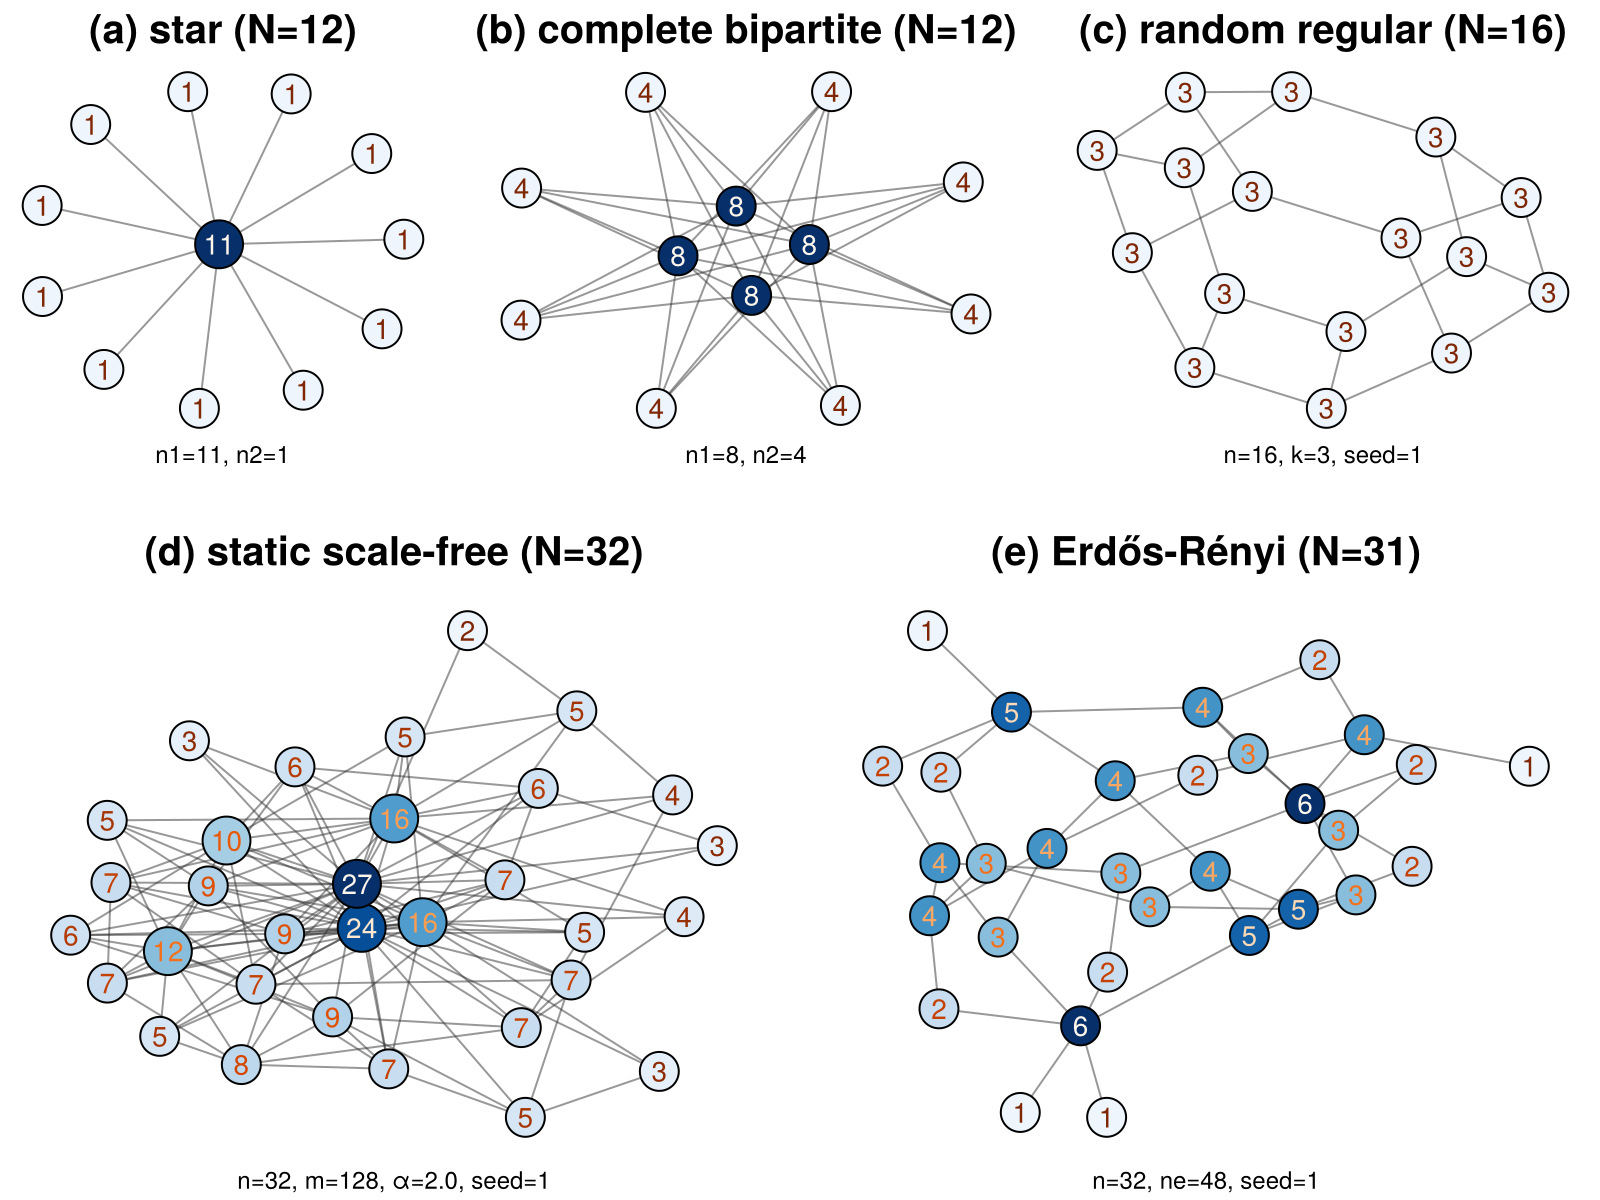

In [8]:
let ifsave = true
    fig = Figure(size=(800, 600), figure_padding=3)
    gl1 = fig[1, 1] = GridLayout()  # row 1
    gl2 = fig[2, 1] = GridLayout()  # row 2
    rowsize!(fig.layout, 1, Auto(2 / 3))
    rowgap!(fig.layout, 30)

    axopts = (; titlesize=20, xautolimitmargin=(0.1, 0.1), yautolimitmargin=(0.1, 0.1))
    # sub GridLayout
    sgl1 = gl1[1, 1] = GridLayout()
    sgl2 = gl1[1, 2] = GridLayout()
    sgl3 = gl1[1, 3] = GridLayout()
    sgl4 = gl2[1, 1] = GridLayout()
    sgl5 = gl2[1, 2] = GridLayout()
    
    t_sgl = (sgl1, sgl2, sgl3, sgl4, sgl5)
    t_axlbl = ("a", "b", "c", "d", "e")
    t_nw = (
        ("star", p_st, gen_star), 
        ("complete bipartite", p_cbg, gen_cbg),
        ("random regular", p_rrg, gen_rrg), 
        ("static scale-free", p_ssf, gen_ssf), 
        ("Erdős-Rényi", p_er, gen_er)
    )

    for (sgl, axlbl, nwtpl) in zip(t_sgl, t_axlbl, t_nw)
        # expand parameters
        nwlbl, nwparam, gen_nw = nwtpl  
        
        # add Axis
        ax = Axis(sgl[1, 1]; axopts...)

        # clear decorations
        hidedecorations!(ax)
        hidespines!(ax)

        # generate a network and visualise it
        g = gen_nw()
        mindeg = minimum(degree(g))
        maxdeg = maximum(degree(g))
        stddeg = (degree(g) .- mindeg) / max(1, (maxdeg - mindeg))
        p = graphplot!(ax, g; 
            node_color=cgrad(:Blues)[0.05 .+ 0.95 * stddeg], 
            ilabels=degree(g), 
            ilabels_color=cgrad(:Oranges, rev=true)[stddeg],
            edge_width=1, edge_color=(:gray20, 0.5)
        )

        # set title
        ax.title = "($axlbl) $nwlbl (N=$(nv(g)))"
        
        # adjust limits
        autolimits!(ax)

        # annotate parameters
        Label(sgl[2, 1], 
            join(["$key=$val" for (key, val) in zip(keys(nwparam), values(nwparam))], ", "),
            tellwidth=false, tellheight=true, fontsize=12,
        )
        rowgap!(sgl, 0)
    end

    colsize!(gl1, 1, Auto(0.8))

    if ifsave save("output/fig-network-ex.pdf", fig) end
    display(fig)
end;